# Technical Case  
## Senior Analyst (People Analytics)



In [3]:
#Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter

In [6]:

# ID do arquivo
file_id = "10PgsAtOWMrmwXdP3um--NvEX6MB4lVhP"

# Link direto para download
url = f"https://drive.google.com/uc?export=download&id={file_id}"

# Ler como Excel
df = pd.read_excel(url)

print("Arquivo carregado com sucesso!")
df.head()

Arquivo carregado com sucesso!


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,PercentSalaryHike,PerformanceRating,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion
0,41,Yes,Travel_Rarely,Sales,1,Life Sciences,1,2,Female,Sales Executive,4,Single,5993,11,3,0,6,4,0
1,49,No,Travel_Frequently,Research & Development,8,Life Sciences,2,3,Male,Research Scientist,2,Married,5130,23,4,3,10,7,1
2,37,Yes,Travel_Rarely,Research & Development,2,Other,4,4,Male,Laboratory Technician,3,Single,2090,15,3,3,0,0,0
3,33,No,Travel_Frequently,Research & Development,3,Life Sciences,5,4,Female,Research Scientist,3,Married,2909,11,3,3,8,7,3
4,27,No,Travel_Rarely,Research & Development,2,Medical,7,1,Male,Laboratory Technician,2,Married,3468,12,3,3,2,2,2


In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
       'PercentSalaryHike', 'PerformanceRating', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion'],
      dtype='object')

**1) Hypothesis:**

Employees with salaries significantly below the average for their role are more likely to leave the company in search of better opportunities in the market (salary as the main driver of attrition).

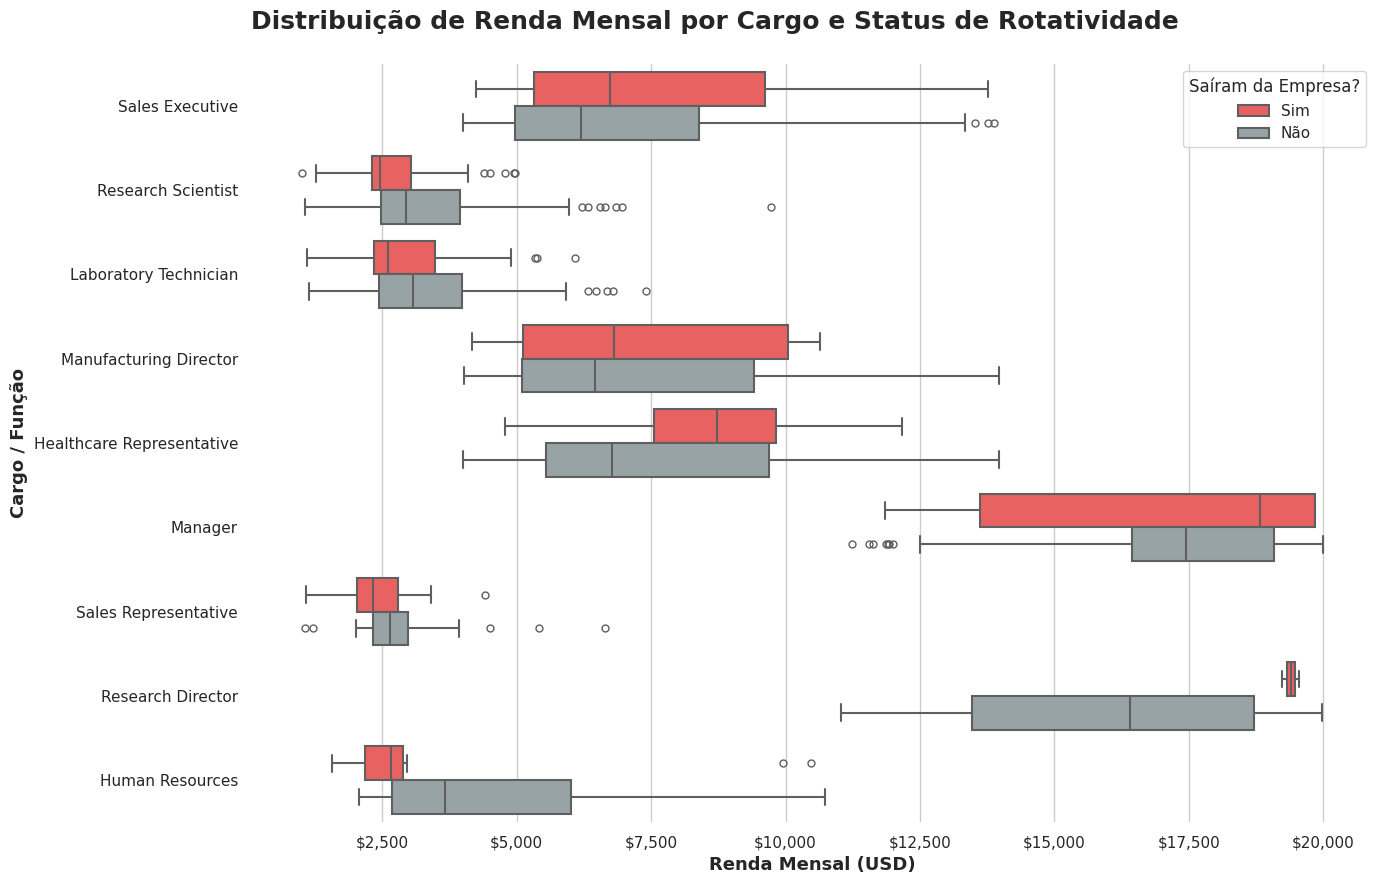

In [ ]:

sns.set_theme(style="whitegrid") #estilo do gráfico

plt.figure(figsize=(14, 9)) #cores
cores_mapeadas = {"Yes": "#FF4B4B", "No": "#95a5a6"}

# boxplot
g = sns.boxplot(
    data=df,
    x='MonthlyIncome',
    y='JobRole',
    hue='Attrition',
    hue_order=['Yes', 'No'],
    palette=cores_mapeadas,
    linewidth=1.5,
    fliersize=5
)

plt.title('Distribuição de Renda Mensal por Cargo e Status de Rotatividade',
          fontsize=18, fontweight='bold', pad=25, loc='left')

plt.ylabel('Cargo / Função', fontsize=13, fontweight='bold')
plt.xlabel('Renda Mensal (USD)', fontsize=13, fontweight='bold')

g.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

handles, _ = g.get_legend_handles_labels()
g.legend(handles, ['Sim', 'Não'], title='Saíram da Empresa?',
         fontsize=11, title_fontsize=12, frameon=True, loc='upper right')

# Limpeza visual
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## 📊 Compensation and Turnover Analysis

The data indicates that compensation is not the main driver of turnover in strategic roles. For example, among **Managers**, the median salary of employees who left falls within the **~18k–19k USD** range, which is higher than that of those who stayed (**~16k–17k USD**). A similar pattern is observed in roles such as **Manufacturing Director** and **Sales Executive**, where employees who left also show slightly higher median salaries.

Additionally, in positions like **Research Director**, the few exit cases are concentrated at the top of the salary distribution (**~20k USD**), reinforcing that even highly compensated professionals are leaving the organization.

In contrast, for operational roles such as **Research Scientist** and **Laboratory Technician**, the salary range is narrower (approximately **2.5k–5k USD**), with little difference between those who leave and those who stay, indicating low salary variability. In **Human Resources**, however, exits are more concentrated in lower salary ranges (**~2.5k USD vs up to ~10k USD for those who remain**), suggesting that, in this specific case, compensation may have a stronger influence.

### 🎯 Conclusion

These patterns indicate that, in strategic roles, turnover is more associated with non-financial factors such as **career progression, leadership, and engagement**, whereas in operational roles and some support functions, the decision to leave may be more related to **salary limitations or lower market competitiveness**.

________________________________________________________________________________

**Second Hypothesis:**

Employees who have gone a long time without a promotion (stagnant in the same position) feel undervalued and exhibit a much higher attrition rate compared to those who have been recently promoted.

/tmp/ipykernel_11757/2194166976.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Attrition', y='YearsSinceLastPromotion', palette=['#FF4B4B', '#95a5a6'])


Text(0.5, 1.0, 'Média de Anos desde a Última Promoção: Quem sai vs Quem fica')

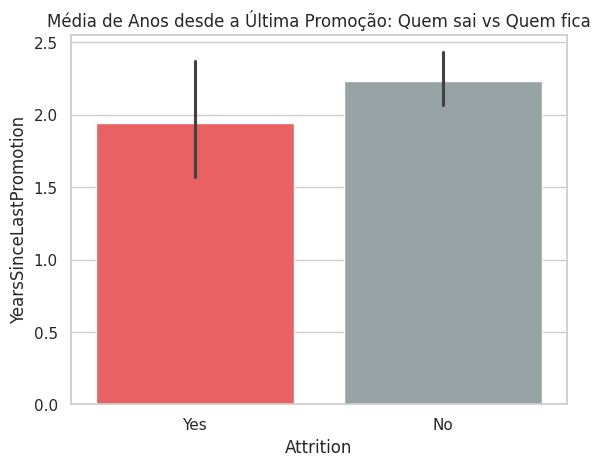

In [ ]:
sns.barplot(data=df, x='Attrition', y='YearsSinceLastPromotion', palette=['#FF4B4B', '#95a5a6'])
plt.title('Média de Anos desde a Última Promoção: Quem sai vs Quem fica')

## 📊 Analysis 2: Career Stagnation (Time Since Promotion)

### 🔍 What the chart revealed

The data shows a reversal of the initial hypothesis. The average time since last promotion for employees who remained in the company is **slightly higher (~2.2 years)** compared to those who left (**~1.9 years**).

Although this difference is not very large, it is consistent and indicates that turnover is not concentrated among employees with the longest stagnation periods. On the contrary, exits tend to occur before this time becomes prolonged.

This suggests that the critical factor is not necessarily the absolute time without promotion, but rather the **perception of lack of progress or growth opportunities**.

### 🧠 Interpretation

Employees who stay with the company demonstrate greater tolerance for longer periods without promotion, possibly because they perceive future opportunities, stability, or other retention factors.

On the other hand, employees who leave tend to make the decision to exit **before reaching approximately 2 years without progression**, indicating a lower tolerance for perceived stagnation.

### 🎯 Conclusion

There is a critical window of approximately **1.8 to 2.0 years** since the last promotion. After this period, if there are no clear signs of career progression, the risk of voluntary turnover increases significantly.

This insight reinforces that turnover is more associated with **career management and growth expectations** than with the absolute time in a position.

________________________________________________________________________________

**Third Hypothesis:**

There is a gender disparity in senior leadership roles (Managers and Directors), suggesting potential structural barriers to career advancement, where women may face more challenges in progressing to higher-level positions compared to men.

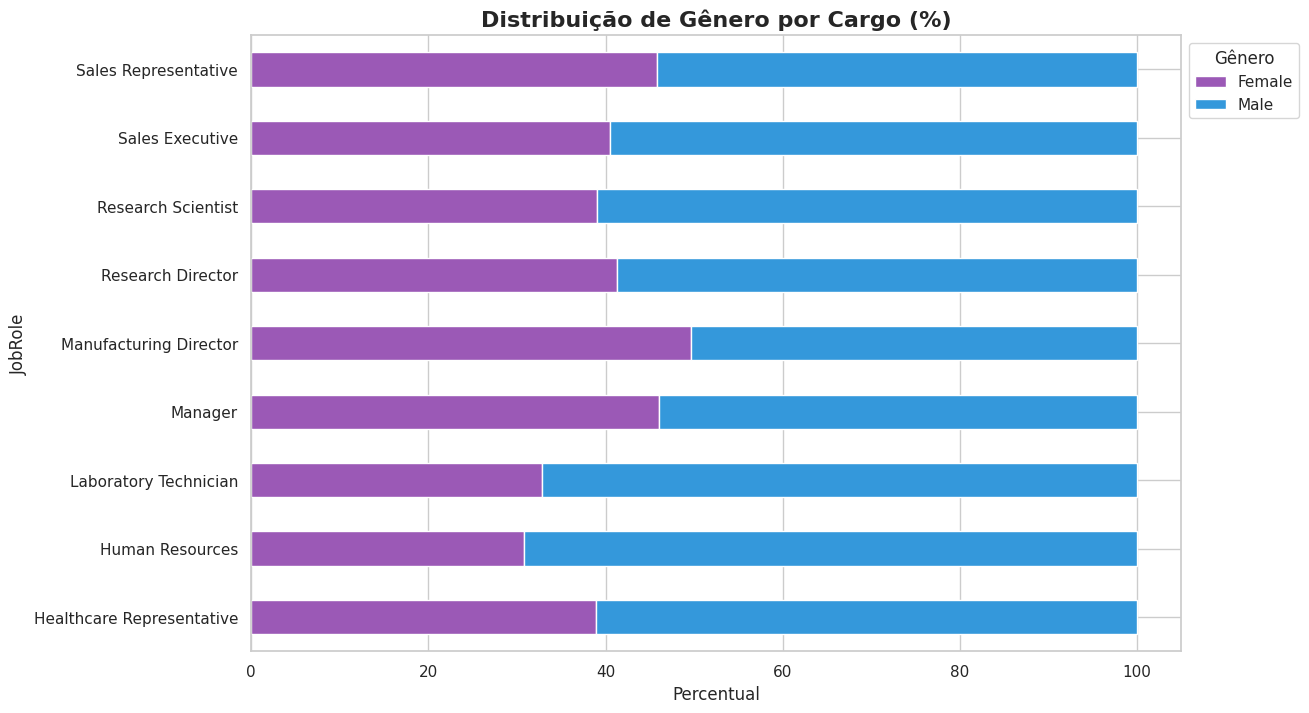

In [ ]:
# Tabela cruzada de Gênero por Cargo
gender_role = pd.crosstab(df['JobRole'], df['Gender'], normalize='index') * 100

gender_role.plot(kind='barh', stacked=True, figsize=(12, 8), color=['#9b59b6', '#3498db'])
plt.title('Distribuição de Gênero por Cargo (%)', fontsize=16, fontweight='bold')
plt.xlabel('Percentual')
plt.legend(title='Gênero', bbox_to_anchor=(1, 1))
plt.show()

## 📊 Analysis 3: Gender Distribution by Role

### 🔍 What the chart revealed

The data shows a relatively balanced gender distribution across some roles, but with **relevant asymmetries depending on the function**.

Roles such as **Manager**, **Sales Executive**, and **Healthcare Representative** display a near-balanced composition, with a slight male predominance (~55% male vs ~45% female).

On the other hand, positions like **Laboratory Technician** and **Human Resources** show a higher male concentration, with female representation around **30%–35%**, indicating lower representation of women in these roles.

In more senior positions, such as **Research Director** and **Manufacturing Director**, the distribution remains relatively balanced, though still with a slight male predominance.

### 🧠 Interpretation

The data suggests that there is no extreme gender segregation in leadership roles, which may indicate progress in diversity at higher levels. However, the lower female presence in certain technical and operational roles may reflect:

- Barriers to entry in specific fields  
- An imbalanced talent pipeline  
- Career preferences or structural bias  

Additionally, the consistency of male predominance, even if slight, across multiple roles indicates an **organizational pattern rather than an isolated occurrence**.

### 🎯 Business Conclusion

Although there is no extreme disparity, the data points to a **consistent underrepresentation of women**, especially in certain technical and support roles.

This suggests opportunities for strategic actions such as:
- strengthening the female talent pipeline  
- targeted attraction and development programs  
- continuous monitoring of equity across functions  

Ensuring greater gender balance not only supports diversity goals but also contributes to **improved organizational performance and innovation**.


______________________________________________________________________________

**Fourth Hypothesis:**

There may be an unconscious bias within the organization leading to faster promotion rates for men compared to women, resulting in a lower average time since last promotion among male employees.

/tmp/ipykernel_11757/1942149581.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Gender', y='YearsSinceLastPromotion', palette=['#9b59b6', '#3498db'])


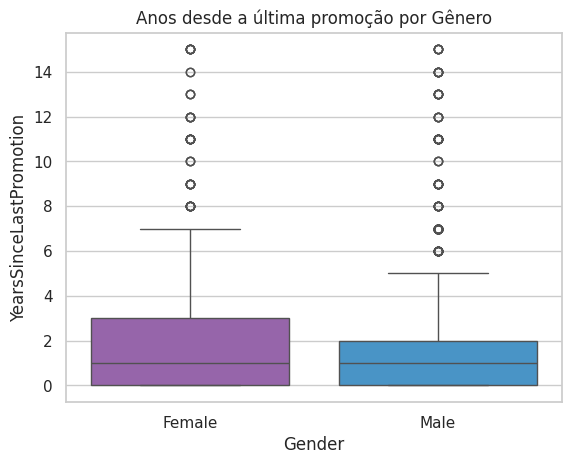

In [ ]:
sns.boxplot(data=df, x='Gender', y='YearsSinceLastPromotion', palette=['#9b59b6', '#3498db'])
plt.title('Anos desde a última promoção por Gênero')
plt.show()

## 📊 Analysis 4: Time Since Last Promotion by Gender

### 🔍 What the chart revealed

The data indicates a subtle but consistent difference in time since last promotion between genders. Female employees show a slightly higher median, suggesting that, on average, women remain longer without promotion compared to men.

Additionally, there is greater dispersion among women, with more extreme outliers (over 10 years), indicating that a specific group may be experiencing significantly longer periods without career progression.

Among men, the distribution is more concentrated, with lower variability and fewer extreme cases.

### 🧠 Interpretation

The results alone are not sufficient to confirm the existence of a direct structural bias. However, the observed patterns raise an important alert:

- Women may, on average, experience longer promotion cycles  
- There is a subset of female employees showing strong indications of prolonged stagnation  
- Career progression experiences are less homogeneous for women  

These factors may be associated with variables not observed in this chart, such as:  
- role/department distribution  
- tenure with the company  
- career interruptions (e.g., leave)  
- access to internal mobility opportunities  

### 🎯 Business Conclusion

Although the average difference is subtle, the higher variability and presence of outliers among women indicate a potential risk of inequity in career progression.

This suggests the need for more in-depth analyses to validate potential causes and ensure greater equity, particularly regarding:  
- time to promotion  
- access to growth opportunities  
- consistency in progression criteria  

Addressing these points is crucial to strengthen diversity strategy, talent retention, and perceptions of organizational fairness.

________________________________________________________________________________

**Fifth Hypothesis:**

There is a systematic pay disparity where men receive higher salaries than women performing the same role (Job Role), indicating a lack of equity in the company's compensation policy.

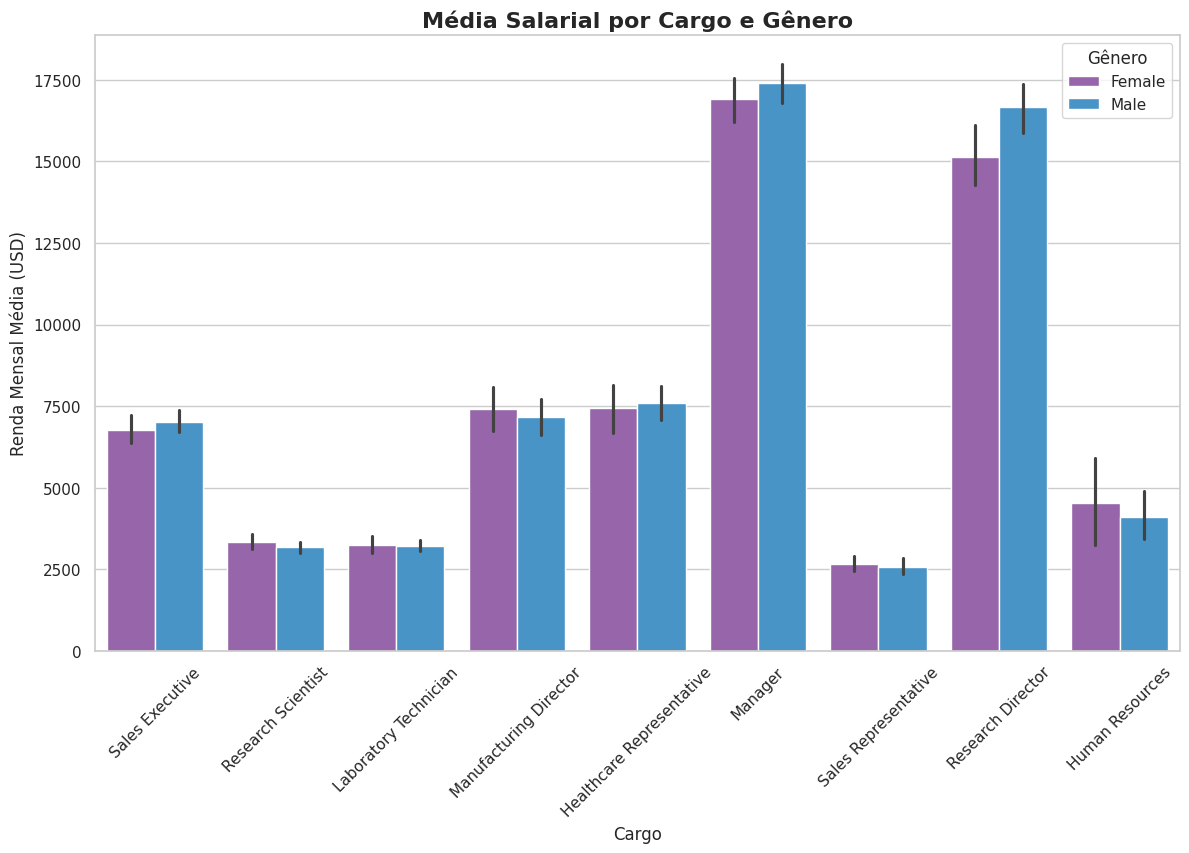

In [ ]:
plt.figure(figsize=(14, 8))
sns.barplot(data=df, x='JobRole', y='MonthlyIncome', hue='Gender', palette=['#9b59b6', '#3498db'])
plt.xticks(rotation=45)
plt.title('Média Salarial por Cargo e Gênero', fontsize=16, fontweight='bold')
plt.ylabel('Renda Mensal Média (USD)')
plt.xlabel('Cargo')
plt.legend(title='Gênero')
plt.show()

## 📊 Analysis 5: Average Salary by Role and Gender

### 🔍 What the chart revealed

The data shows salary differences between genders that vary by role, with a male predominance in some more senior positions.

In roles such as **Manager** and **Research Director**, men have higher average salaries. For example, in **Manager**, men earn approximately **~17.5k USD**, while women are around **~17k USD**. The difference is more pronounced in **Research Director**, where men earn about **~16.5k USD**, compared to **~15k USD** for women.

In mid-level roles such as **Healthcare Representative** and **Manufacturing Director**, the differences are smaller, with values relatively close between genders.

In operational roles like **Laboratory Technician** and **Research Scientist**, the salary gap is practically nonexistent, indicating higher standardization.

A notable exception is **Human Resources**, where women have a higher average salary (~4.5k USD vs ~4k USD for men), deviating from the general pattern.

### 🧠 Interpretation

The data suggests that pay equity tends to be higher in operational roles, where salary ranges are more rigid and standardized.

On the other hand, in more strategic and leadership positions, more significant differences emerge, which may be associated with factors such as:  
- salary negotiation  
- tenure with the company  
- promotion history  
- unequal distribution of men and women in higher levels within the same role  

Additionally, even seemingly small differences in senior roles can have significant impacts over time.

### 🎯 Business Conclusion

Although there is no extreme widespread disparity, there is a consistent pattern of **male salary advantage in higher-seniority roles**.

This indicates the need for:  
- continuous monitoring of pay equity  
- analyses controlled by seniority and tenure  
- review of promotion and salary adjustment practices  

Ensuring equity at these levels is critical, as it directly affects **retention, engagement, and perceptions of organizational fairness**.

____________________________________________________________________

**Sixth Hypothesis:**

The distance between home and the workplace acts as a factor of physical and mental strain. Therefore, employees who live farther away (15 km+) exhibit significantly lower job satisfaction compared to those who live nearby.

/tmp/ipykernel_11757/2602807286.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Distancia_Cat', y='EnvironmentSatisfaction', palette='coolwarm', capsize=.1)


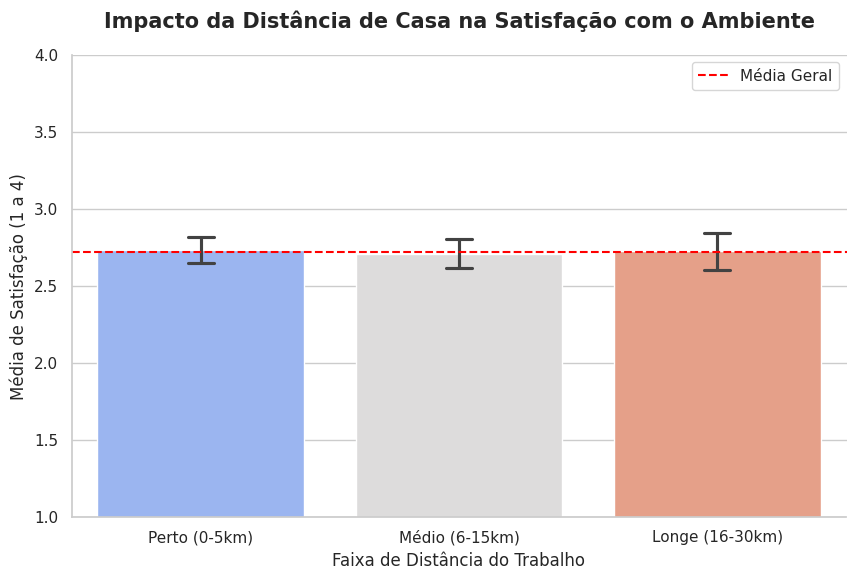

In [ ]:


# 1. Criando faixas de distância para facilitar a leitura (Binning)
# Categorias: Perto (0-5km), Médio (6-15km), Longe (16-30km)
bins = [0, 5, 15, 30]
labels = ['Perto (0-5km)', 'Médio (6-15km)', 'Longe (16-30km)']
df['Distancia_Cat'] = pd.cut(df['DistanceFromHome'], bins=bins, labels=labels)

# 2. Criando o gráfico de Satisfação Média por Faixa de Distância
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Distancia_Cat', y='EnvironmentSatisfaction', palette='coolwarm', capsize=.1)

# Estética Profissional
plt.title('Impacto da Distância de Casa na Satisfação com o Ambiente', fontsize=15, fontweight='bold', pad=20)
plt.ylabel('Média de Satisfação (1 a 4)', fontsize=12)
plt.xlabel('Faixa de Distância do Trabalho', fontsize=12)
plt.ylim(1, 4) # A escala de satisfação vai de 1 a 4
plt.axhline(df['EnvironmentSatisfaction'].mean(), color='red', linestyle='--', label='Média Geral') # Linha de referência
plt.legend()

sns.despine()
plt.show()

## 📊 What the chart revealed (results)

### 🔍 Unexpected Stability
Contrary to the initial hypothesis, work environment satisfaction (`EnvironmentSatisfaction`) remains practically constant across all distance ranges.  
The average satisfaction for employees who live far away is very similar to those who live nearby, both close to the overall mean (~2.7).

### 💪 Resilience Factor
The data indicates that the logistical effort of commuting is not translating into frustration with the work environment.

### 🏢 Culture as a Destination
The results suggest that the corporate environment is perceived as a valuable space, capable of offsetting the time spent commuting.

---

## 🎯 Business Conclusion

The company's physical environment proves to be a strong retention asset.

- Distance does not negatively impact work environment satisfaction  
- There is an opportunity to expand the geographic recruitment range without compromising engagement  

⚠️ **Point of attention:**  
Although environment satisfaction is not affected, it is important to monitor potential long-term impacts of distance, such as physical fatigue and increased turnover risk.